# Visualization of the benchmarking results for the Kleins et al. dataset

Include the plots for
1. Fate accuracy
2. W2 for test population
3. W2 for each clone

Please run the following notebooks in order before this step
`scripts/benchmarking/1.fate_acc_for_all.ipynb`  
`scripts/benchmarking/2.w2_for_all.ipynb`   
`scripts/benchmarking/3.w2_per_clone.ipynb`    

In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [ ]:
os.chdir("/rds/user/wz369/hpc-work/pseudodynamics_plus")

In [38]:
def setup_style():
    plt.rcParams.update({
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.1,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    sns.set_style("ticks")

In [39]:
setup_style()

## load performance

In [3]:
overall_performance = pd.read_csv("results/benchmarking/klein_overall_performs_May8.csv")
overall_performance.head(3)

,accuracy,w2_raw,space,method,pearson_r
0,0.479074,0.006539,DM10,pseudodynamics+,0.911810
1,0.422944,0.006672,DM10,pseudodynamics+,0.861627
2,0.408173,0.006931,DM10,pseudodynamics+,0.844051


In [21]:
overall_performance = pd.read_csv("results/benchmarking/klein_overall_performs_May8.csv")

methods = [
    "OTCFM", "SF2M", "pseudodynamics+",
    "PRESCIENT", "TrajectoryNet",
    "MIOFlow", "TIGON",
    "scDiffEq", "DeepRUOTv2"
]
colors = [
    "#505175", "#7C8DBE", "#C5D9ED",
    "#FFE7BD", "#EFB397",
    "#D087A3", "#A1689E",
    "#88B5A3",  # sage green (scDiffeq)
    "#D4856E",  # terracotta (DeepRUOTv2)
]

model_palette = dict(zip(methods, colors))

In [34]:
model_palette

{'OTCFM': '#505175',
 'SF2M': '#7C8DBE',
 'pseudodynamics+': '#C5D9ED',
 'PRESCIENT': '#FFE7BD',
 'TrajectoryNet': '#EFB397',
 'MIOFlow': '#D087A3',
 'TIGON': '#A1689E',
 'scDiffEq': '#88B5A3',
 'DeepRUOTv2': '#D4856E'}

In [5]:
overall_performance['color'] = overall_performance['method'].map(model_palette)

# fate accuray

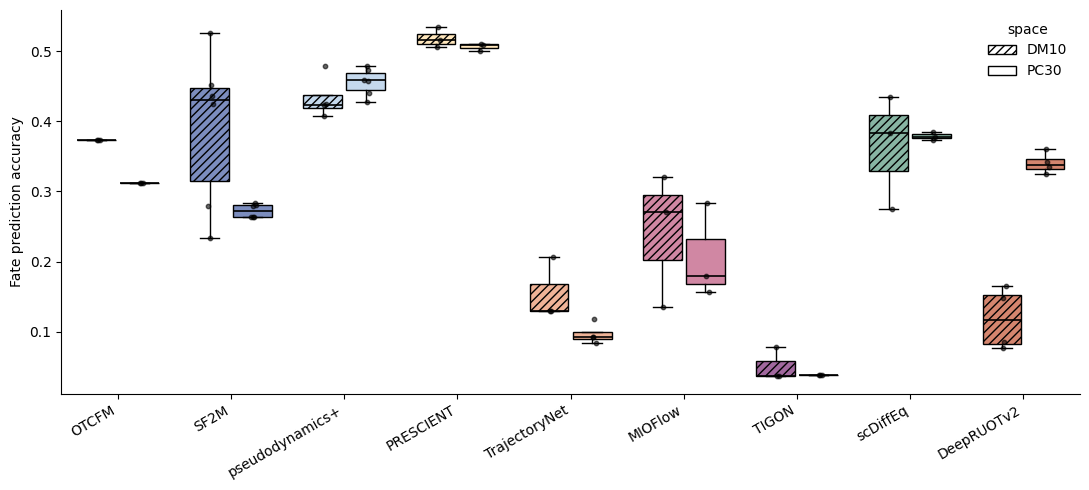

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


spaces = ["DM10", "PC30"]

fig, ax = plt.subplots(figsize=(11, 5))

width = 0.38
offsets = {"DM10": -width / 2, "PC30": +width / 2}

for i, method in enumerate(methods):
    for space in spaces:
        sub = overall_performance.query("method == @method and space == @space")["accuracy"].dropna().values
        if len(sub) == 0:
            continue
        pos = i + offsets[space]
        bp = ax.boxplot(
            sub,
            positions=[pos],
            widths=width * 0.9,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=1.0),
            capprops=dict(color="black", linewidth=1.0),
            boxprops=dict(linewidth=1.0),
        )
        box = bp["boxes"][0]
        box.set_facecolor(model_palette[method])
        box.set_edgecolor("black")
        if space == "DM10":
            box.set_hatch("////")

        # overlay individual points
        jitter = (np.random.RandomState(0).rand(len(sub)) - 0.5) * width * 0.4
        ax.scatter(np.full(len(sub), pos) + jitter, sub,
                   s=10, color="black", alpha=0.6, zorder=3)

ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Fate prediction accuracy")
ax.set_xlim(-0.5, len(methods) - 0.5)

space_legend = [
    Patch(facecolor="white", edgecolor="black", hatch="////", label="DM10"),
    Patch(facecolor="white", edgecolor="black", label="PC30"),
]
ax.legend(handles=space_legend, title="space", loc="upper right", frameon=False)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1237326/4259384820.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub,
/tmp/ipykernel_1237326/4259384820.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_1237326/4259384820.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub,
/tmp/ipykernel_1237326/4259384820.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),


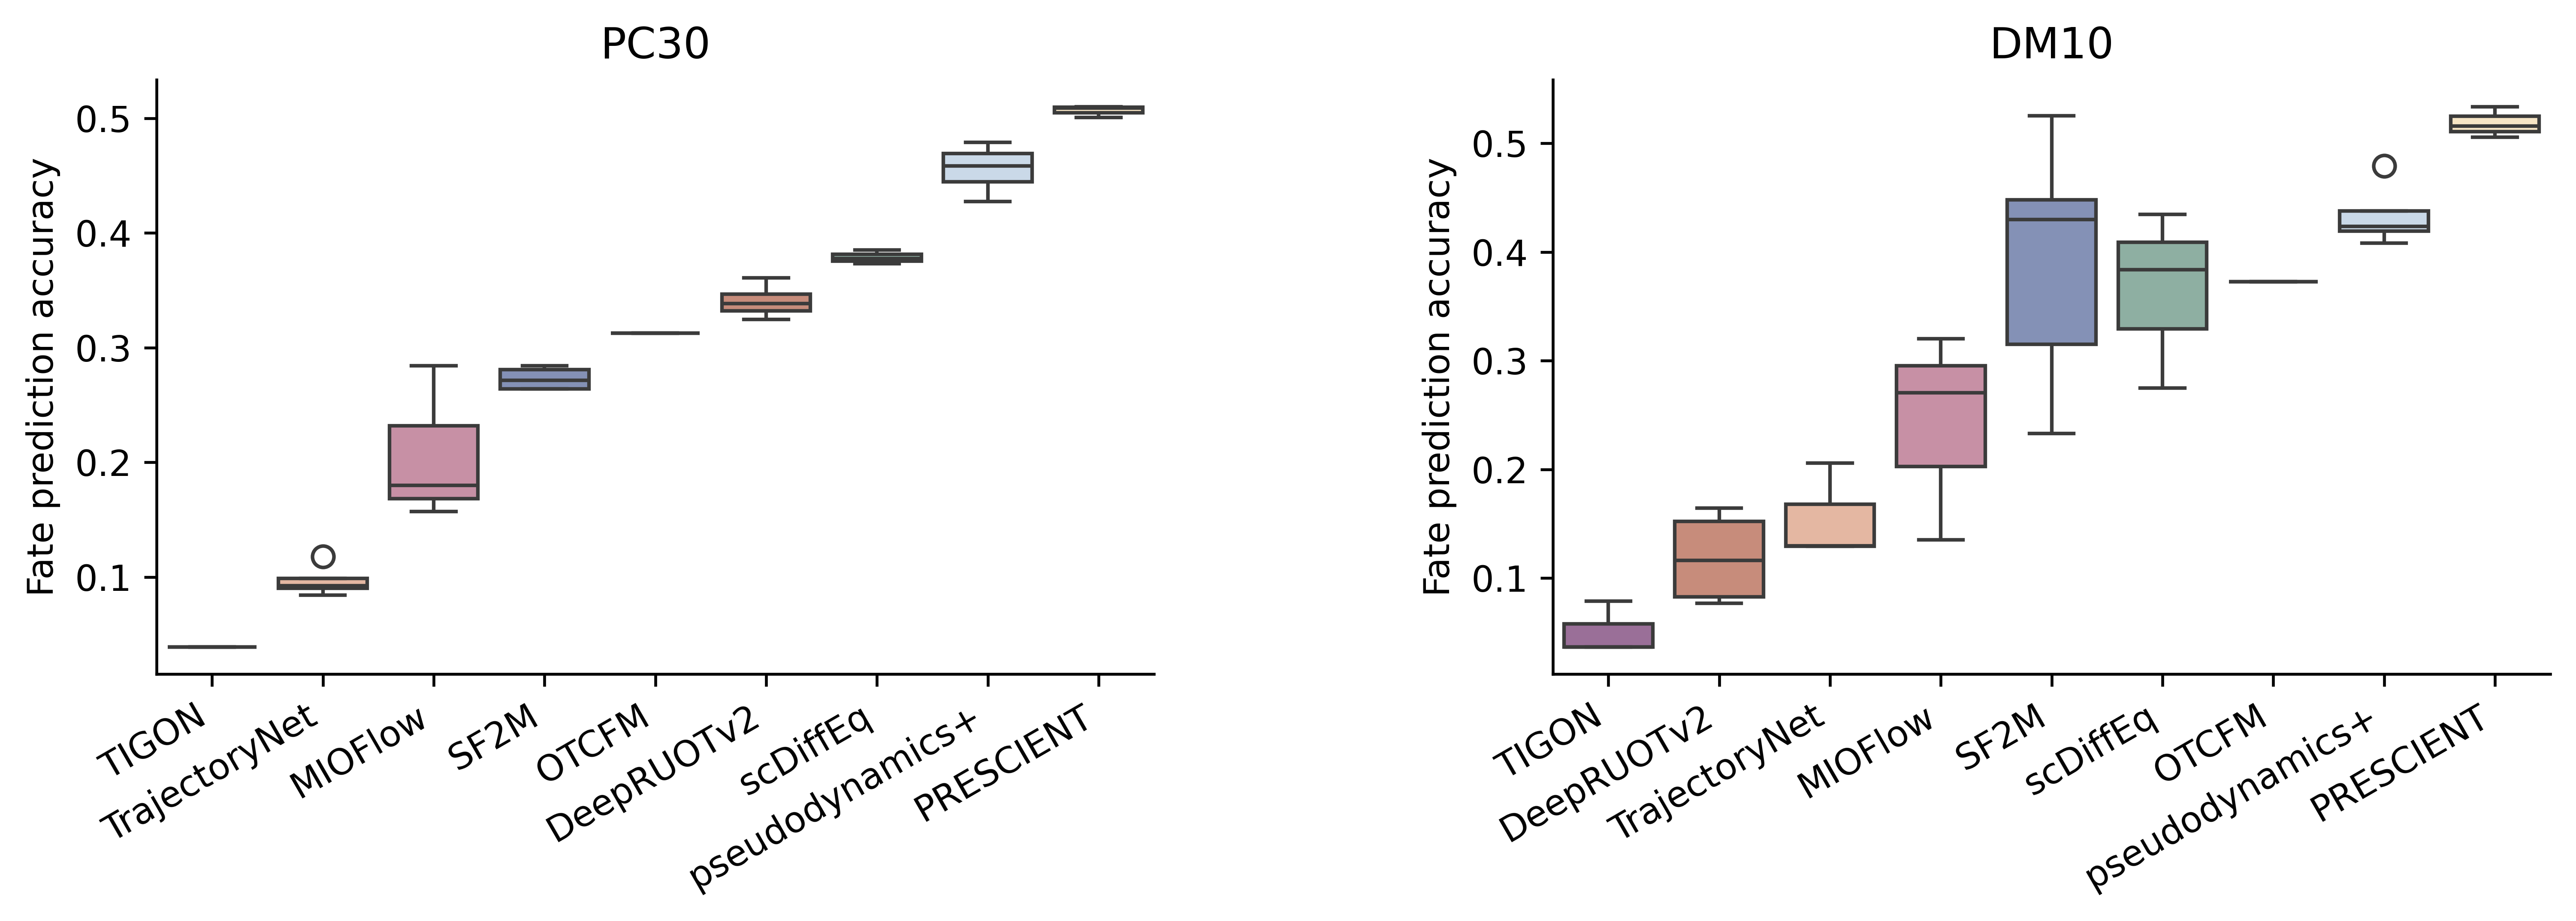

In [19]:


fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=600,gridspec_kw={'wspace': 0.4})
for i, space in enumerate(["PC30","DM10"]):
    sub = overall_performance.query("`space` == @space").sort_values("accuracy")

    sns.boxplot(data=sub, 
                x="method", y="accuracy", ax=axes[i],
                palette=model_palette
                )
    ax=axes[i]
    ax.set_ylabel("Fate prediction accuracy")
    ax.set_xlim(-0.5, len(methods) - 0.5)
    ax.set_title(space)
    ax.set_xticklabels(ax.get_xticklabels(),
                            rotation=30, ha="right")
    
    ax.set_xlabel("")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

In [20]:
fig_dir = '/rds/user/wz369/hpc-work/pseudodynamics_plus/results/benchmarking'
fig.savefig(f"{fig_dir}/fate_acc_benchmark_results.pdf", bbox_inches="tight", transparent=True)

# W2

## PC

/tmp/ipykernel_1237326/3862730947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub,
/tmp/ipykernel_1237326/3862730947.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_1237326/3862730947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub,
/tmp/ipykernel_1237326/3862730947.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),


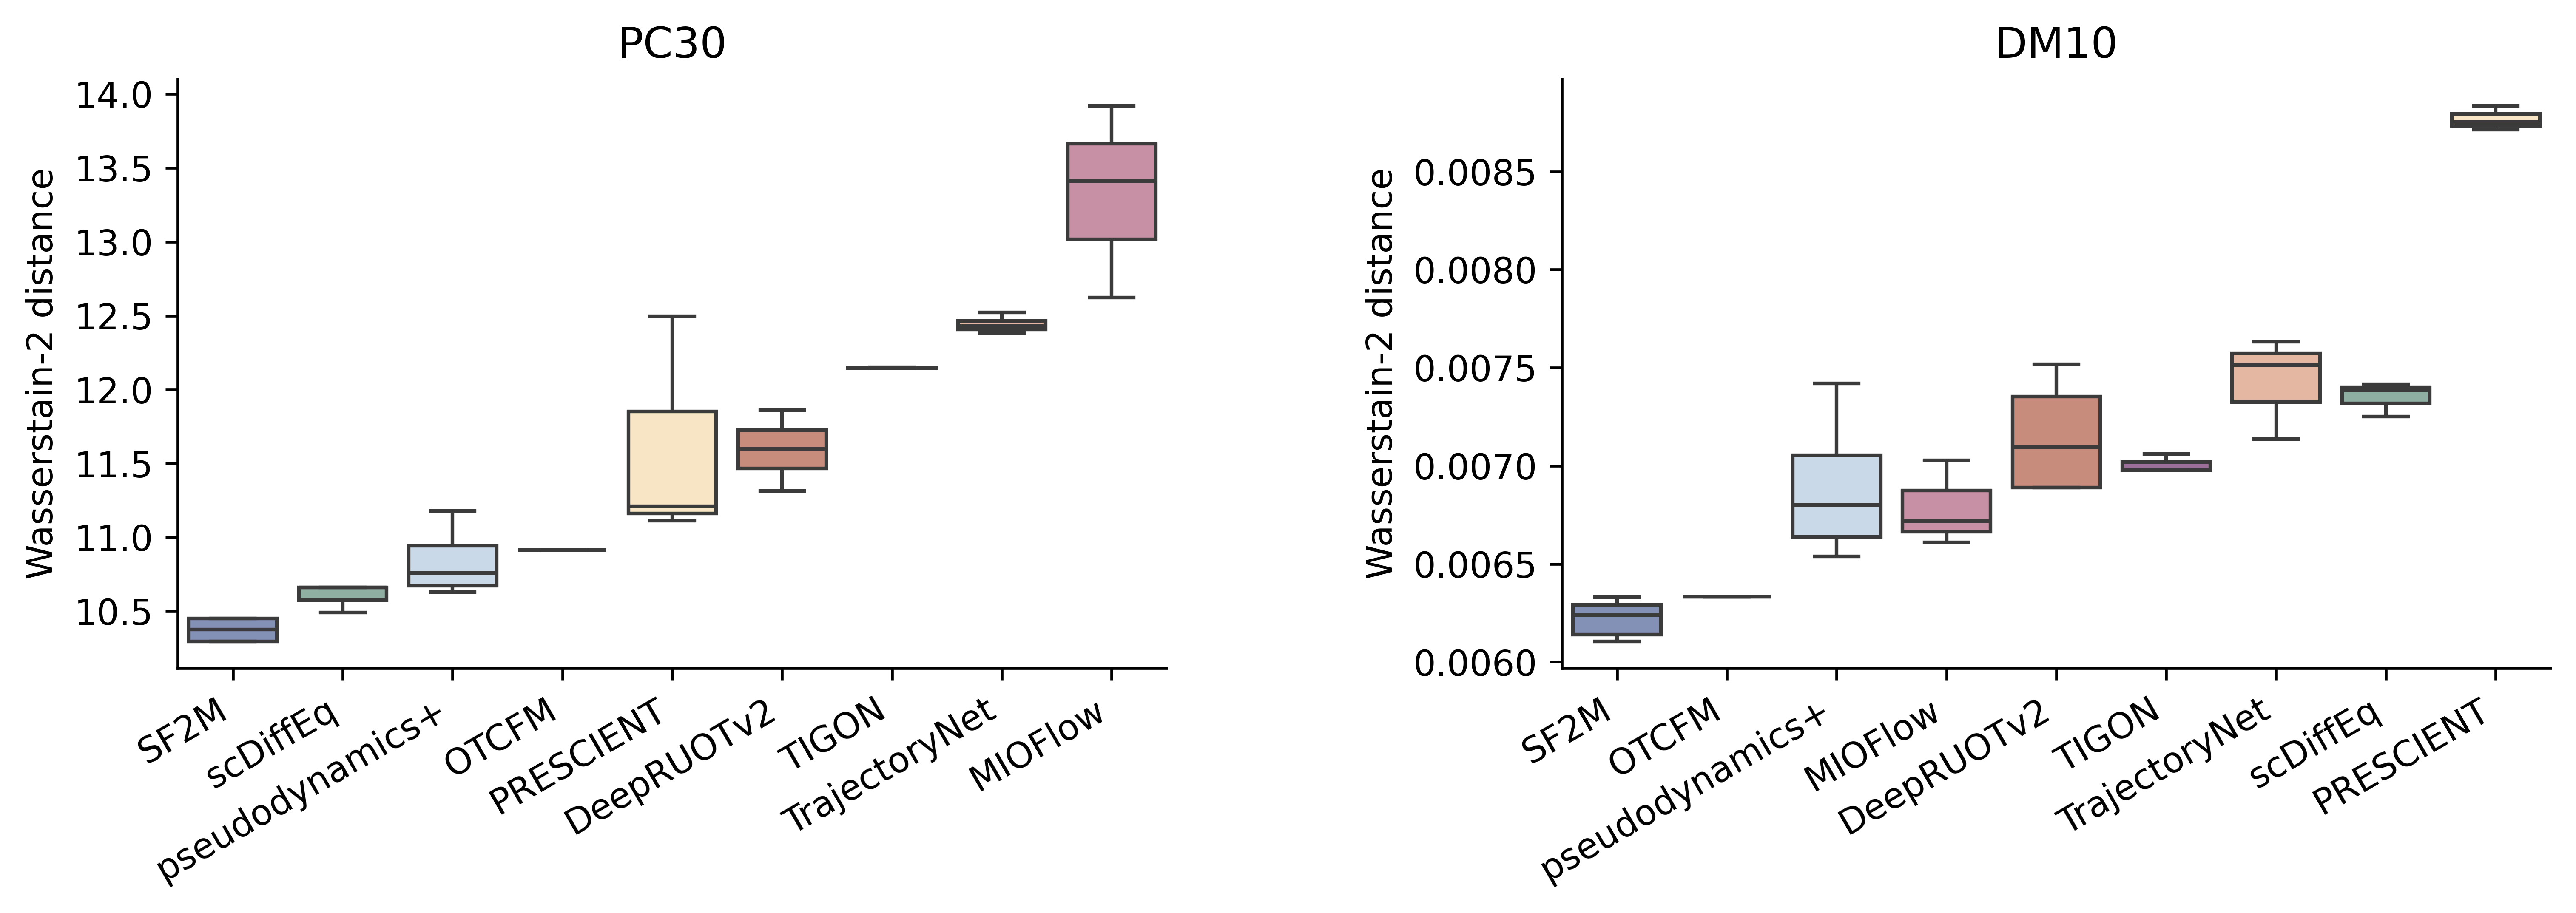

In [17]:


fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=600, gridspec_kw={'wspace': 0.4})
for i, space in enumerate(["PC30","DM10"]):
    sub = overall_performance.query("`space` == @space").sort_values("w2_raw")

    sns.boxplot(data=sub, 
                x="method", y="w2_raw", ax=axes[i],
                palette=model_palette
                )
    ax=axes[i]
    ax.set_ylabel("Wasserstain-2 distance")
    ax.set_xlim(-0.5, len(methods) - 0.5)
    ax.set_title(space)
    ax.set_xticklabels(ax.get_xticklabels(),
                            rotation=30, ha="right")
    
    ax.set_xlabel("")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

In [18]:
fig_dir = '/rds/user/wz369/hpc-work/pseudodynamics_plus/results/benchmarking'
fig.savefig(f"{fig_dir}/w2_benchmark_results.pdf", bbox_inches="tight", transparent=True)

## Per-clone W2

In [22]:
per_clone_df = pd.read_csv(f"results/benchmarking/klein_per_clone_w2_all.csv")
per_clone_df

,method,space,clone,w2_raw_mean,w2_raw_std,w2_scaled_mean,n_runs,clone_size_src,clone_size_tgt,clone_size_d6,dominant_fate,multipotency,pseudotime_spread,clone_size_d4,initial_var_dm,initial_var_pc
0,DeepRUOT,dm10,Clone_1099,0.010157,0.000344,0.010157,4,9,47,47,Neutrophil,1,0.053959,9,0.297773,3.337828
1,DeepRUOT,dm10,Clone_123,0.006198,0.000747,0.006198,4,5,20,20,Monocyte,2,0.157227,5,0.037467,6.415137
2,DeepRUOT,dm10,Clone_1258,0.006871,0.000235,0.006871,4,3,22,22,Mast,2,0.099004,3,20.624729,26.133310
3,DeepRUOT,dm10,Clone_1301,0.004316,0.000614,0.004316,4,4,30,30,Monocyte,1,0.037938,4,0.061860,6.198031
4,DeepRUOT,dm10,Clone_1305,0.004129,0.000238,0.004129,4,5,28,28,Meg,1,0.017980,5,0.555030,26.428597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1641,scDiffEq,pc30,Clone_777,14.870185,0.206588,14.870185,3,1,22,22,Erythroid,2,0.174897,1,NaN,NaN
1642,scDiffEq,pc30,Clone_862,6.344935,0.217838,6.344935,3,3,21,21,undiff,0,0.030168,3,0.026816,6.807424
1643,scDiffEq,pc30,Clone_961,18.703031,0.049745,18.703031,3,1,23,23,Monocyte,1,0.052457,1,NaN,NaN
1644,scDiffEq,pc30,Clone_965,8.423396,0.171055,8.423396,3,9,11,11,Neutrophil,1,0.043359,9,0.328130,4.715086


In [37]:
per_clone_df['method'].unique()

array(['DeepRUOT', 'MIOFlow', 'OTCFM', 'PRESCIENT', 'SF2M', 'TIGON',
       'TrajectoryNet', 'pdp+', 'scDiffEq'], dtype=object)

<Axes: xlabel='method', ylabel='w2_raw_mean'>

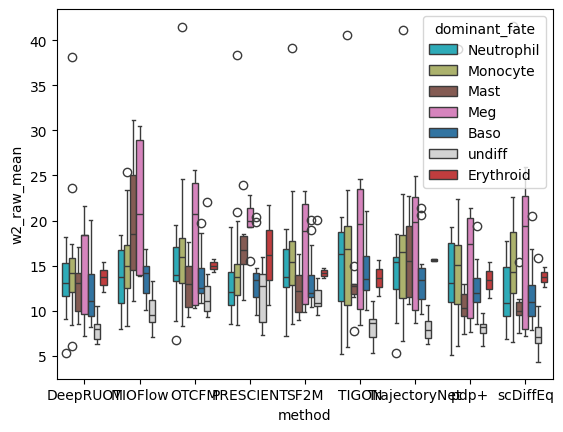

In [33]:
celltype_palette = dict(zip(adata.obs['Annotation'].cat.categories,adata.uns['Annotation_colors']))
celltype_palette['undiff'] = '#D3D3D3'
sns.boxplot(
    data = per_clone_df.query("`space` == 'pc30'"),
    x = "method",
    y = "w2_raw_mean",
    hue = "dominant_fate",
    palette = celltype_palette,
)

In [27]:
adata = sc.read_h5ad("data/klein_addpop.h5ad")
adata

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split', 'bifate_mask'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'DM_scaler', 'Meta clones_colors', 'PC_scaler', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'DM_EigenVectors_scaled', 'X_diffmap', 'X_pca', 'X_pca_scaled', 'X_umap', 'delta_DM', 'delta_PC', 'guassian_kde_u_DM_EigenVectors', 'palantir_fate_probabilities'
    varm: 'P

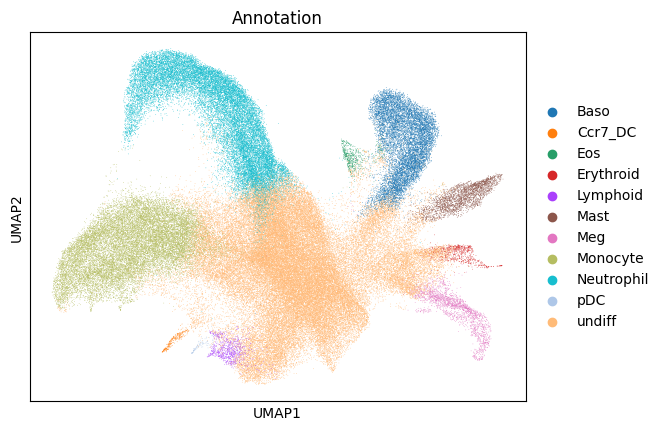

In [29]:
sc.pl.umap(adata, color=['Annotation'])

In [ ]:
fate_counts = best["dominant_fate"].value_counts()
fates_to_show = fate_counts[fate_counts >= 3].index.tolist()
d = best[best["dominant_fate"].isin(fates_to_show)]
if not d.empty:
    fate_order = (d.groupby("dominant_fate")["w2_raw_mean"]
                    .median().sort_values().index.tolist())
    sns.boxplot(data=d, x="dominant_fate", y="w2_raw_mean",
                order=fate_order, ax=ax, palette="Set2")
    sns.stripplot(data=d, x="dominant_fate", y="w2_raw_mean",
                    order=fate_order, ax=ax, color="black", size=3, alpha=0.5)
ax.set_xlabel("Dominant fate (day 6)")
ax.set_ylabel("Per-clone W2")
ax.set_title(f"(a) W2 by fate type ({best_method})")
ax.tick_params(axis="x", rotation=45)